# CASE 01 Decision Dashboard

## tl;dr

이 노트북은 통계와 KPI 결과를 matplotlib 한 페이지 PNG로 압축합니다. 산출물은 `evidence/dashboard/01_one_page_decision.png`입니다.

**RFM 기준일:** 2011-12-10

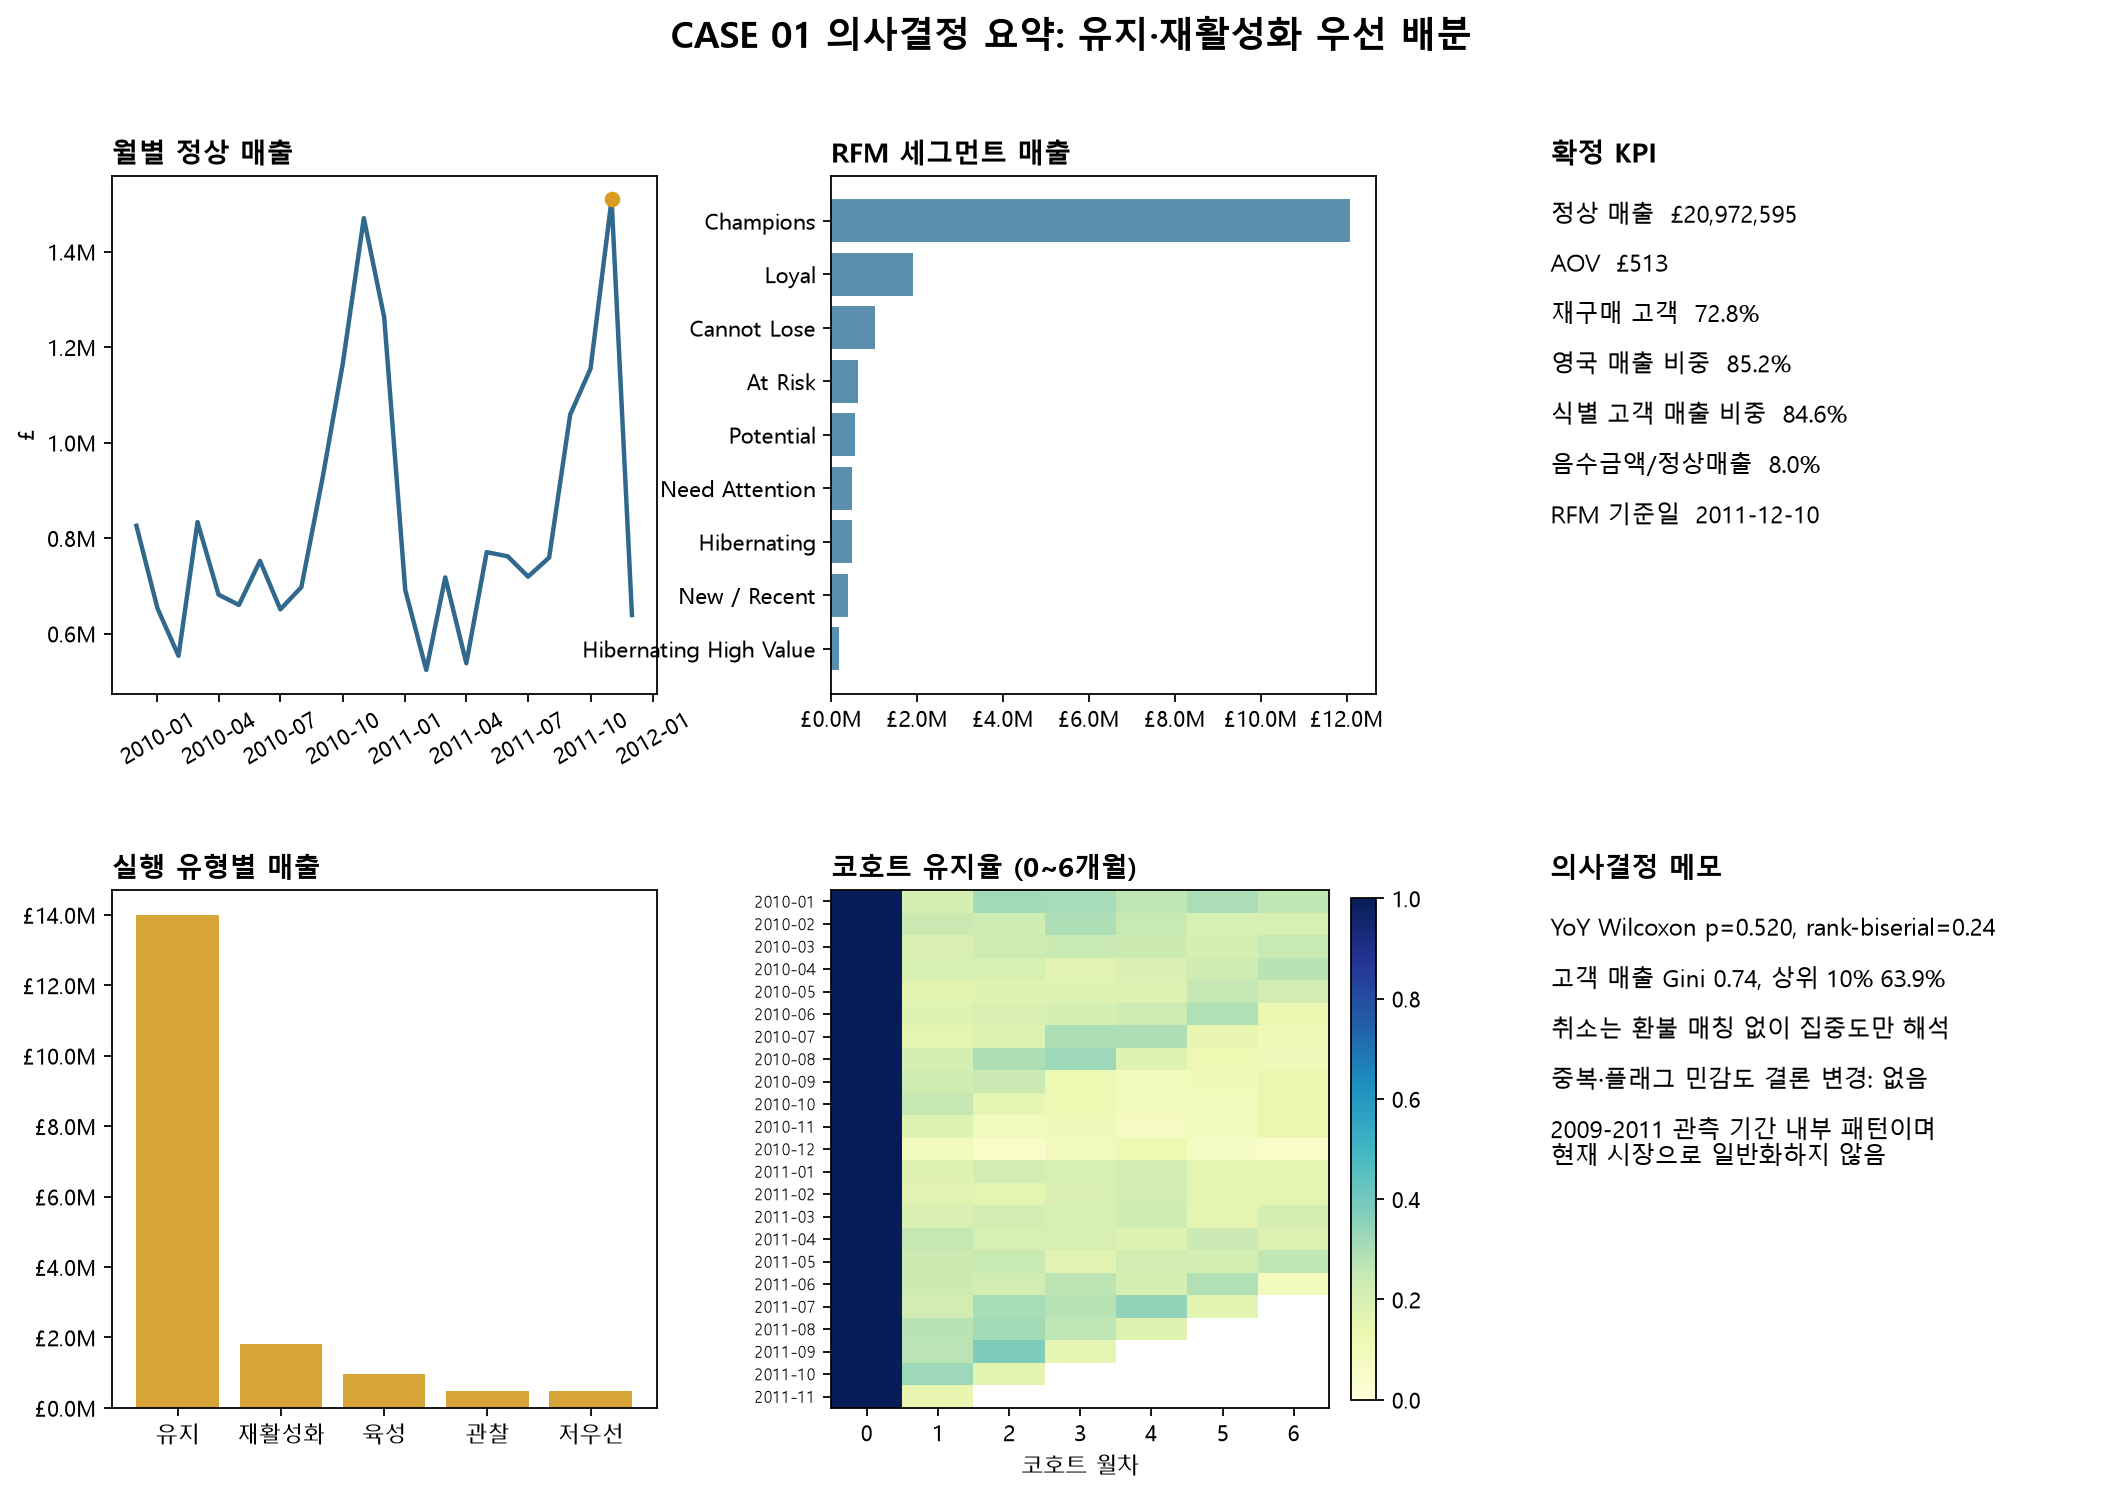

In [1]:
from pathlib import Path
import hashlib
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

pd.set_option("display.max_columns", None)

CASE_NAME = "01_retail_customer_analytics"
case_dir_candidates = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd() / "cases" / CASE_NAME,
]
case_dir = next(
    (path.resolve() for path in case_dir_candidates
     if (path / "data" / "raw" / "online_retail_II.xlsx").exists()),
    None,
)
if case_dir is None:
    raise FileNotFoundError(
        "online_retail_II.xlsx를 찾지 못했습니다. 저장소 루트 또는 notebooks 폴더에서 실행하세요."
    )

sys.path.insert(0, str(case_dir / "src"))
from data_preparation import load_and_prepare_retail_data
from decision_dashboard import save_decision_dashboard
from kpi_segmentation import run_kpi_segmentation
from statistical_analysis import run_statistical_analysis

raw_path = case_dir / "data" / "raw" / "online_retail_II.xlsx"
figure_dir = case_dir / "evidence" / "dashboard"
figure_dir.mkdir(parents=True, exist_ok=True)
prepared = load_and_prepare_retail_data(raw_path)
stats = run_statistical_analysis(prepared)
kpis = run_kpi_segmentation(prepared)
source_sha256 = hashlib.sha256(raw_path.read_bytes()).hexdigest().upper()
assert source_sha256 == "BCBE73B35F5B7BABF197FB0CB983A11F5D9FF929078D4AA53D171B1F2DF2E980"

dashboard_path = save_decision_dashboard(
    stats, kpis, figure_dir / "01_one_page_decision.png"
)
display(Markdown(f"**RFM 기준일:** {kpis.snapshot_date:%Y-%m-%d}"))
display(Image(filename=str(dashboard_path)))

## Decision table

In [2]:
display(kpis.priority.style.format({
    "customers": "{:,.0f}",
    "revenue": "£{:,.0f}",
    "customer_share": "{:.1%}",
    "revenue_share": "{:.1%}",
    "median_recency": "{:.0f}",
}))
display(kpis.values)
print("분석용 SQL 뷰는 sql/03_analysis_views.sql이다. 시각화 source of truth는 이 PNG다.")

,segment,action,customers,revenue,customer_share,revenue_share,median_recency,priority_note
2,Champions,유지,"1,290","£12,083,792",21.9%,68.1%,16,현재 매출 기여가 큰 활성 고객. 서비스 유지 우선.
5,Loyal,유지,703,"£1,915,519",12.0%,10.8%,78,현재 매출 기여가 큰 활성 고객. 서비스 유지 우선.
1,Cannot Lose,재활성화,229,"£1,021,613",3.9%,5.8%,333,과거 가치가 있으나 최근성이 낮음. 재활성화 후보.
0,At Risk,재활성화,599,"£616,182",10.2%,3.5%,377,과거 가치가 있으나 최근성이 낮음. 재활성화 후보.
4,Hibernating High Value,재활성화,65,"£183,879",1.1%,1.0%,423,과거 가치가 있으나 최근성이 낮음. 재활성화 후보.


,kpi,value,unit
0,Gross sales,2.097259e+07,GBP
1,Observed net transaction value,1.928725e+07,GBP
2,Completed orders,4.091100e+04,orders
3,AOV,5.126395e+02,GBP / order
4,Identified customers,5.878000e+03,customers
5,Identified-customer revenue share,8.460293e-01,share
6,Repeat-customer rate,7.276284e-01,share
7,UK revenue share,8.521110e-01,share
8,Negative-value-to-gross ratio,8.037716e-02,ratio
9,Peak complete-month gross sales,1.509496e+06,GBP (2011-11)


분석용 SQL 뷰는 sql/03_analysis_views.sql이다. 시각화 source of truth는 이 PNG다.


### Interpretation boundary

- 이 화면은 관측 기간의 완료 매출과 RFM 라벨만 보여 줍니다.
- 날짜를 최신 연도로 바꾸거나 예측 시각을 추가하지 않습니다.
- 실행 제안의 문장 근거는 `INSIGHTS.md`로 이어집니다.